In [ ]:
!git clone --quiet --recursive https://github.com/cvg/Hierarchical-Localization/
%cd /content/Hierarchical-Localization
!pip install --progress-bar off --quiet -e .
!pip install --progress-bar off --quiet --upgrade plotly

/content/Hierarchical-Localization
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from pprint import pformat

from hloc import extract_features, match_features, localize_inloc, visualization

In [ ]:
dataset = Path("datasets/inloc/")  # В цю директорію будуть завантажені зображення для мапінгу

pairs = Path("pairs/inloc/")  # В цю директорію будуть завантажені пари зображень для мапінгу
loc_pairs = pairs / "pairs-sfm.txt"  # В цей файл будуть записані пари зображень для локалізації

outputs = Path("outputs/inloc/")  # В цю директорію будуть зберігатися результати роботи
results = outputs / "InLoc_hloc_superpoint+superglue_netvlad40.txt"  # В цей файл буде записаний результат

In [ ]:
print(f"Конфігурації для детекції особливостей:\n{pformat(extract_features.confs)}")
print(f"Конфігурації для співставлення особливостей:\n{pformat(match_features.confs)}")

Конфігурації для детекції особливостей:
{'aliked-n16': {'model': {'model_name': 'aliked-n16', 'name': 'aliked'},
                'output': 'feats-aliked-n16',
                'preprocessing': {'grayscale': False, 'resize_max': 1024}},
 'd2net-ss': {'model': {'multiscale': False, 'name': 'd2net'},
              'output': 'feats-d2net-ss',
              'preprocessing': {'grayscale': False, 'resize_max': 1600}},
 'dir': {'model': {'name': 'dir'},
         'output': 'global-feats-dir',
         'preprocessing': {'resize_max': 1024}},
 'disk': {'model': {'max_keypoints': 5000, 'name': 'disk'},
          'output': 'feats-disk',
          'preprocessing': {'grayscale': False, 'resize_max': 1600}},
 'megaloc': {'model': {'name': 'megaloc'},
             'output': 'global-feats-megaloc',
             'preprocessing': {'resize_max': 1024}},
 'netvlad': {'model': {'name': 'netvlad'},
             'output': 'global-feats-netvlad',
             'preprocessing': {'resize_max': 1024}},
 'openibl': {

In [ ]:
%cd /content/Hierarchical-Localization
images = Path('datasets/inloc')
outputs = Path('outputs/inloc/')
!rm -rf $outputs
sfm_pairs = outputs / 'pairs-sfm.txt'
loc_pairs = outputs / 'pairs-loc.txt'
sfm_dir = outputs / 'sfm'
features = outputs / 'features.h5'
matches = outputs / 'matches.h5'

feature_conf = extract_features.confs['disk']
matcher_conf = match_features.confs['disk+lightglue']

/content/Hierarchical-Localization


13 зображень для мапінгу


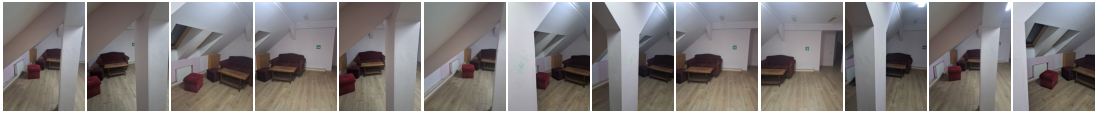

In [ ]:
from hloc import extract_features, match_features, reconstruction, visualization, pairs_from_exhaustive
from hloc.visualization import plot_images, read_image
from hloc.utils import viz_3d
references = [str(p.relative_to(images)) for p in (images).iterdir()]
print(len(references), "зображень для мапінгу")
plot_images([read_image(images / r) for r in references], dpi=25)

In [ ]:
extract_features.main(feature_conf, images, image_list=references, feature_path=features)
pairs_from_exhaustive.main(sfm_pairs, image_list=references)
match_features.main(matcher_conf, sfm_pairs, features=features, matches=matches)

[2025/04/08 20:02:37 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 5000, 'name': 'disk'},
 'output': 'feats-disk',
 'preprocessing': {'grayscale': False, 'resize_max': 1600}}
[2025/04/08 20:02:37 hloc INFO] Skipping the extraction.
[2025/04/08 20:02:37 hloc INFO] Found 78 pairs.
[2025/04/08 20:02:37 hloc INFO] Matching local features with configuration:
{'model': {'features': 'disk', 'name': 'lightglue'},
 'output': 'matches-disk-lightglue'}
100%|██████████| 66/66 [46:21<00:00, 42.15s/it]
[2025/04/08 20:48:59 hloc INFO] Finished exporting matches.


PosixPath('outputs/inloc/matches.h5')

In [ ]:
model = reconstruction.main(sfm_dir, images, sfm_pairs, features, matches, image_list=references)

[2025/04/08 21:26:59 hloc INFO] Creating an empty database...
[2025/04/08 21:26:59 hloc INFO] Importing images into the database...
[2025/04/08 21:27:00 hloc INFO] Importing features into the database...
100%|██████████| 13/13 [00:00<00:00, 465.33it/s]
[2025/04/08 21:27:00 hloc INFO] Importing matches into the database...
100%|██████████| 78/78 [00:00<00:00, 593.98it/s]
[2025/04/08 21:27:00 hloc INFO] Performing geometric verification of the matches...
[2025/04/08 21:27:02 hloc INFO] Running 3D reconstruction...
[2025/04/08 21:28:07 hloc INFO] Reconstructed 1 model(s).
[2025/04/08 21:28:07 hloc INFO] Largest model is #0 with 13 images.
[2025/04/08 21:28:07 hloc INFO] Reconstruction statistics:
Reconstruction:
	num_cameras = 13
	num_images = 13
	num_reg_images = 13
	num_points3D = 6833
	num_observations = 34343
	mean_track_length = 5.02605
	mean_observations_per_image = 2641.77
	mean_reprojection_error = 1.17994
	num_input_images = 13


In [ ]:
fig = viz_3d.init_figure()
viz_3d.plot_reconstruction(fig, model, color='rgba(255,0,0,0.5)', name="mapping", points_rgb=True)
fig.show()

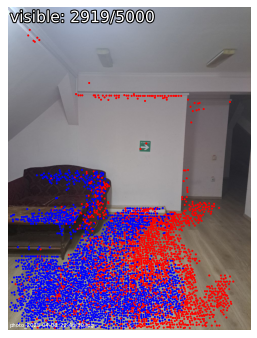

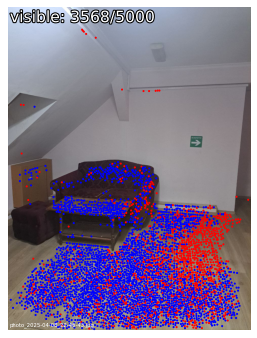

In [ ]:
visualization.visualize_sfm_2d(model, images, selected=[3,4], color_by='visibility', n=2)

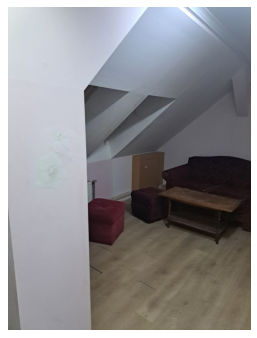

In [ ]:
query = 'query/test.jpg'
plot_images([read_image(images / query)], dpi=75)

In [ ]:
references_registered = [model.images[i].name for i in model.reg_image_ids()]
extract_features.main(feature_conf, images, image_list=[query], feature_path=features, overwrite=True)
pairs_from_exhaustive.main(loc_pairs, image_list=[query], ref_list=references_registered)
match_features.main(matcher_conf, loc_pairs, features=features, matches=matches, overwrite=True);

[2025/04/08 21:39:47 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 5000, 'name': 'disk'},
 'output': 'feats-disk',
 'preprocessing': {'grayscale': False, 'resize_max': 1600}}
100%|██████████| 1/1 [00:27<00:00, 27.13s/it]
[2025/04/08 21:40:14 hloc INFO] Finished exporting features.
[2025/04/08 21:40:14 hloc INFO] Found 13 pairs.
[2025/04/08 21:40:14 hloc INFO] Matching local features with configuration:
{'model': {'features': 'disk', 'name': 'lightglue'},
 'output': 'matches-disk-lightglue'}
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning:

This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.

100%|██████████| 13/13 [0

found 1456/2381 inlier correspondences.


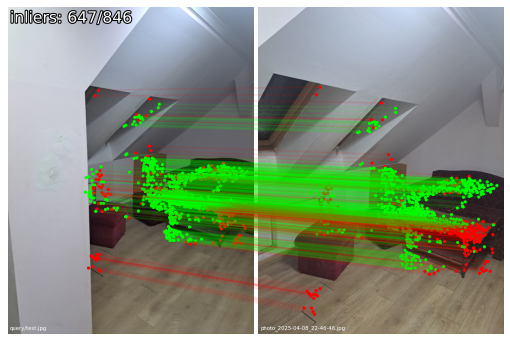

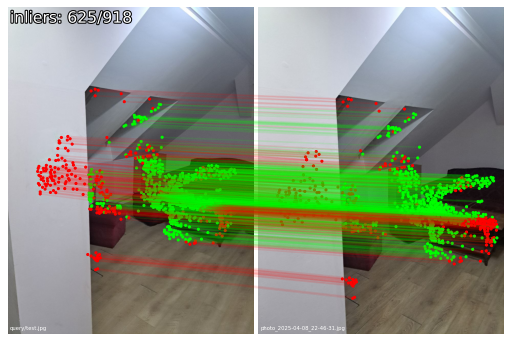

In [ ]:
import pycolmap
from hloc.localize_sfm import QueryLocalizer, pose_from_cluster

camera = pycolmap.infer_camera_from_image(images / query)
ref_ids = [model.find_image_with_name(n).image_id for n in references_registered]
conf = {
    'estimation': {'ransac': {'max_error': 12}},
    'refinement': {'refine_focal_length': True, 'refine_extra_params': True},
}
localizer = QueryLocalizer(model, conf)
ret, log = pose_from_cluster(localizer, query, camera, ref_ids, features, matches)

print(f'found {ret["num_inliers"]}/{len(ret["inlier_mask"])} inlier correspondences.')
visualization.visualize_loc_from_log(images, query, log, model)

In [ ]:
pose = pycolmap.Image(cam_from_world=ret['cam_from_world'])
viz_3d.plot_camera_colmap(fig, pose, camera, color='rgba(0,255,0,0.5)', name=query, fill=True)
# visualize 2D-3D correspodences
import numpy as np
inl_3d = np.array([model.points3D[pid].xyz for pid in np.array(log['points3D_ids'])[ret['inlier_mask']]])
viz_3d.plot_points(fig, inl_3d, color="lime", ps=1, name=query)
fig.show()